In [1]:
# ==============================================================================
# 0. ENVIRONMENT CHECK
# ==============================================================================
import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device    : {DEVICE}')

PyTorch version : 2.5.1+cu121
CUDA available  : True
GPU             : NVIDIA GeForce RTX 3060
Using device    : cuda


In [2]:
# ==============================================================================
# 1. IMPORTS
# ==============================================================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

try:
    from tqdm.auto import tqdm
except ImportError:
    class _NoOpTqdm:
        def __init__(self, iterable, **kwargs):
            self.iterable = iterable
        def __iter__(self):
            return iter(self.iterable)
        def set_postfix(self, *args, **kwargs):
            pass
    def tqdm(iterable, **kwargs):
        return _NoOpTqdm(iterable, **kwargs)

In [3]:
# ==============================================================================
# 2. CONFIGURATION
# ==============================================================================
class Config:
    """Central configuration — update DATA_DIR to your actual path."""
    DATA_DIR       = r'D:\dataset'
    IMAGE_DIR      = os.path.join(DATA_DIR, 'images/')
    MASK_DIR       = os.path.join(DATA_DIR, 'mask/')
    METADATA_CSV   = os.path.join(DATA_DIR, 'metadata\HAM10000_metadata.csv')
    ENCODER_CKPT   = r'D:\kimi phase 6\encoder\swinunet_v4_encoder.pth'
    CHECKPOINT_DIR = r'D:\Kimi phase 6\checkpoints'

    # Backward-compatible aliases
    ENCODER_CHECKPOINT = ENCODER_CKPT
    SAVE_DIR = CHECKPOINT_DIR

    # Training
    SEED = 42
    IMG_SIZE = 224
    BATCH_SIZE = 32
    NUM_WORKERS = 0
    NUM_CLASSES = 7

    # Phase 1 (frozen encoder)
    PHASE1_EPOCHS = 10
    PHASE1_LR = 1e-3

    # Phase 2 (unfrozen encoder)
    PHASE2_EPOCHS = 50
    ENCODER_LR = 1e-5
    HEAD_LR = 5e-5

    # Early stopping
    EARLY_STOPPING_PATIENCE = 10

    # V10 Hyperparameters
    FOCAL_GAMMA = 2.0
    LAMBDA_ENTROPY = 0.1      # Entropy regularization weight
    MC_DROPOUT_T = 50         # Number of MC Dropout passes
    DROPOUT_P = 0.3           # Dropout probability (stays ON at inference)

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# ==============================================================================
# 3. REPRODUCIBILITY
# ==============================================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [5]:
# ==============================================================================
# 4. MORPHOLOGY EXTRACTION
# ==============================================================================
def extract_morphology(mask_np):
    mask_bin = (mask_np > 0.5).astype(np.uint8)
    result = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = result[0] if len(result) == 2 else result[1]

    if not contours:
        return np.zeros(5, dtype=np.float32)

    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    if area < 10 or perimeter < 1:
        return np.zeros(5, dtype=np.float32)

    asymmetry = 0.0
    if len(cnt) >= 5:
        try:
            _, axes, _ = cv2.fitEllipse(cnt)
            major = max(axes)
            minor = min(axes)
            if major > 0:
                asymmetry = 1.0 - (minor / major)
        except Exception:
            asymmetry = 0.0

    compactness = (4.0 * np.pi * area) / (perimeter ** 2 + 1e-8)
    border_irregularity = 1.0 - compactness
    color_variance = 0.0
    diameter = np.sqrt(4.0 * area / np.pi) / 224.0

    return np.array([asymmetry, border_irregularity, color_variance,
                     compactness, diameter], dtype=np.float32)


def extract_morphology_with_color(mask_np, image_np):
    features = extract_morphology(mask_np)
    mask_bin = (mask_np > 0.5).astype(np.uint8)
    if mask_bin.sum() > 0:
        masked_pixels = image_np[mask_bin > 0]
        if len(masked_pixels) > 0:
            color_std = np.std(masked_pixels, axis=0).mean()
            features[2] = color_std / 50.0
    return features

In [6]:
# ==============================================================================
# 5. DATASET (with missing-modality support)
# ==============================================================================
class HAM10000Dataset_Multimodal(Dataset):
    """
    Returns dict with keys: image, mask, morphology, metadata, availability flags, label.
    Missing modalities are returned as zero tensors plus availability=0 so DataLoader
    can collate mixed-present/mixed-missing samples.
    """
    def __init__(self, df, img_dir, mask_dir, transform=None, mode='train',
                 img_size=224, sex_map=None, site_to_idx=None,
                 missing_meta_prob=0.0, missing_morph_prob=0.0):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.mode = mode
        self.img_size = img_size
        self.sex_map = sex_map or {'male': 0.0, 'female': 1.0, 'unknown': 2.0}
        self.site_to_idx = site_to_idx or {}
        self.missing_meta_prob = missing_meta_prob
        self.missing_morph_prob = missing_morph_prob

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['image_id']
        label = int(row['label'])

        # Load image
        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")
        image = np.array(Image.open(img_path).convert("RGB"))

        # Load mask
        mask_path = os.path.join(self.mask_dir, f"{img_id}_segmentation.png")
        if not os.path.exists(mask_path):
            mask_path = os.path.join(self.mask_dir, f"{img_id}.png")
        mask = np.array(Image.open(mask_path).convert("L")) / 255.0

        # Resize
        image_resized = cv2.resize(image, (self.img_size, self.img_size))
        mask_resized = cv2.resize(mask.astype(np.float32), (self.img_size, self.img_size))

        # Extract morphology (before albumentations)
        if random.random() > self.missing_morph_prob:
            morphology = extract_morphology_with_color(mask_resized, image_resized)
            morphology = torch.tensor(morphology, dtype=torch.float32)
            morphology_available = torch.tensor(1.0, dtype=torch.float32)
        else:
            morphology = torch.zeros(5, dtype=torch.float32)
            morphology_available = torch.tensor(0.0, dtype=torch.float32)

        # Encode metadata
        if random.random() > self.missing_meta_prob:
            age = row['age'] if not pd.isna(row['age']) else 50.0
            age_norm = age / 100.0
            sex_val = self.sex_map.get(row['sex'], 2.0)
            site_val = self.site_to_idx.get(row['localization'], 0)
            metadata = torch.tensor([age_norm, sex_val, float(site_val)], dtype=torch.float32)
            metadata_available = torch.tensor(1.0, dtype=torch.float32)
        else:
            metadata = torch.zeros(3, dtype=torch.float32)
            metadata_available = torch.tensor(0.0, dtype=torch.float32)

        # Albumentations
        if self.transform:
            augmented = self.transform(image=image_resized, mask=mask_resized)
            image = augmented['image']
            mask = augmented['mask']
        else:
            image = torch.from_numpy(image_resized.transpose(2, 0, 1)).float() / 255.0
            mask = torch.from_numpy(mask_resized).float()

        if isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask).float()
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)
        elif mask.ndim == 3 and mask.shape[-1] == 1:
            mask = mask.permute(2, 0, 1)
        elif mask.ndim == 3 and mask.shape[0] != 1:
            mask = mask.unsqueeze(0)

        return {
            'image': image,
            'mask': mask,
            'morphology': morphology,
            'metadata': metadata,
            'morphology_available': morphology_available,
            'metadata_available': metadata_available,
            'label': torch.tensor(label, dtype=torch.long)
        }

In [7]:
# ==============================================================================
# 6. TRANSFORMS
# ==============================================================================
def get_transforms(img_size=224, mode='train'):
    if mode == 'train':
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.Rotate(limit=30, p=0.5),
            A.ElasticTransform(alpha=1, sigma=50, p=0.3),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
            A.GaussianBlur(blur_limit=3, p=0.3),
            A.CoarseDropout(num_holes_range=(1, 8), hole_height_range=(1, 32),
                            hole_width_range=(1, 32), fill=0, p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])

In [8]:
# ==============================================================================
# 6.5 CUSTOM COLLATE FUNCTION (handles missing metadata/morphology)
# ==============================================================================
def custom_collate_fn(batch):
    batch = [sample for sample in batch if sample is not None]
    if not batch:
        return None

    collated = {}
    for key in batch[0].keys():
        values = [sample[key] for sample in batch]
        if any(value is None for value in values):
            collated[key] = None
        else:
            collated[key] = torch.stack(values, dim=0)

    return collated

In [9]:
# ==============================================================================
# 7. FPN
# ==============================================================================
class FeaturePyramidNetwork(nn.Module):
    def __init__(self, in_channels_list, out_channels=256):
        super().__init__()
        self.lateral_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_ch, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ) for in_ch in in_channels_list
        ])
        self.smooth_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ) for _ in in_channels_list
        ])

    def forward(self, features):
        laterals = [conv(f) for conv, f in zip(self.lateral_convs, features)]
        for i in range(len(laterals) - 1, 0, -1):
            upsampled = F.interpolate(laterals[i], size=laterals[i-1].shape[2:], mode='nearest')
            laterals[i-1] = laterals[i-1] + upsampled
        return [smooth(lat) for smooth, lat in zip(self.smooth_convs, laterals)]

In [10]:
# ==============================================================================
# 8. IMAGE ENCODER (returns pooled + spatial tokens)
# ==============================================================================
class ImageEncoderBranch(nn.Module):
    """
    Swin-B + FPN → pooled feature + spatial tokens for cross-attention
    """
    def __init__(self, encoder_checkpoint, out_dim=256):
        super().__init__()
        self.encoder = timm.create_model(
            'swin_base_patch4_window7_224',
            pretrained=False,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )
        if encoder_checkpoint and os.path.exists(encoder_checkpoint):
            ckpt = torch.load(encoder_checkpoint, map_location='cpu', weights_only=False)
            self.encoder.load_state_dict(ckpt, strict=False)

        self.fpn = FeaturePyramidNetwork([128, 256, 512, 1024], 256)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Linear(256, out_dim)

    def _to_channels_first(self, features):
        expected = [128, 256, 512, 1024]
        out = []
        for i, f in enumerate(features):
            if f.ndim == 4 and f.shape[-1] == expected[i]:
                f = f.permute(0, 3, 1, 2).contiguous()
            out.append(f)
        return out

    def forward(self, image):
        features = self._to_channels_first(self.encoder(image))
        fpn_features = self.fpn(features)

        # P2 for Grad-CAM (56x56)
        p2 = fpn_features[0]  # (B, 256, 56, 56)

        # P4 for spatial tokens (14x14 = 196 tokens)
        p4 = fpn_features[2]  # (B, 256, 14, 14)
        B, C, H, W = p4.shape
        spatial_tokens = p4.view(B, C, H * W).permute(0, 2, 1)  # (B, 196, 256)

        # Pooled feature
        pooled = self.pool(p2).flatten(1)  # (B, 256)
        pooled = self.proj(pooled)  # (B, 256)

        return pooled, spatial_tokens, p2  # p2 for Grad-CAM target

In [11]:
# ==============================================================================
# 9. MODALITY ENCODERS
# ==============================================================================
class MetadataEncoder(nn.Module):
    def __init__(self, num_sites, embed_dim=16, out_dim=256):
        super().__init__()
        self.site_embed = nn.Embedding(num_sites, embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(1 + 1 + embed_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(128, out_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, metadata):
        age = metadata[:, 0:1]
        sex = metadata[:, 1:2]
        site = metadata[:, 2].long()
        site_vec = self.site_embed(site)
        x = torch.cat([age, sex, site_vec], dim=1)
        return self.mlp(x)


class MorphologyEncoder(nn.Module):
    def __init__(self, in_dim=5, out_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(64, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(128, out_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, morphology):
        return self.mlp(morphology)

In [12]:
# ==============================================================================
# 10. BILATERAL CROSS-MODAL ATTENTION FUSION (CORRECTED)
# ==============================================================================
class CrossModalAttentionBlock(nn.Module):
    """
    Query from one modality attends to spatial tokens from image.
    This creates MEANINGFUL attention (query: Bx1x256, KV: Bx196x256)
    """
    def __init__(self, dim=256, num_heads=8, dropout=0.1):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.norm = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(dim * 2, dim),
            nn.Dropout(dropout)
        )
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, query, kv):
        """
        query: (B, 1, D) - pooled modality feature
        kv:    (B, N, D) - spatial tokens from image (N=196)
        """
        attn_out, attn_weights = self.cross_attn(query, kv, kv)
        out = self.norm(query + attn_out)
        out = self.norm2(out + self.ffn(out))
        return out, attn_weights


class BCMAF(nn.Module):
    """
    Bilateral Cross-Modal Attention Fusion (CORRECTED)
    All modalities attend to IMAGE SPATIAL TOKENS
    """
    def __init__(self, dim=256, num_heads=8, dropout=0.1):
        super().__init__()

        # All blocks attend to image spatial tokens
        self.img_self_attn = CrossModalAttentionBlock(dim, num_heads, dropout)
        self.meta_to_img = CrossModalAttentionBlock(dim, num_heads, dropout)
        self.morph_to_img = CrossModalAttentionBlock(dim, num_heads, dropout)

        # Projection for enriched features
        self.img_proj = nn.Linear(dim, dim)
        self.meta_proj = nn.Linear(dim, dim)
        self.morph_proj = nn.Linear(dim, dim)

    def forward(self, img_pooled, img_spatial, meta_feat, morph_feat):
        """
        img_pooled:   (B, 256)
        img_spatial:  (B, 196, 256)
        meta_feat:    (B, 256)
        morph_feat:   (B, 256)
        """
        # Add sequence dimension
        img_q = img_pooled.unsqueeze(1)    # (B, 1, 256)
        meta_q = meta_feat.unsqueeze(1)    # (B, 1, 256)
        morph_q = morph_feat.unsqueeze(1)  # (B, 1, 256)

        # Block A: Image self-attention on spatial tokens
        img_enriched, attn_img = self.img_self_attn(img_q, img_spatial)

        # Block B: Metadata attends to image spatial tokens
        meta_enriched, attn_meta = self.meta_to_img(meta_q, img_spatial)

        # Block C: Morphology attends to image spatial tokens
        morph_enriched, attn_morph = self.morph_to_img(morph_q, img_spatial)

        # Project
        img_enriched = self.img_proj(img_enriched.squeeze(1))
        meta_enriched = self.meta_proj(meta_enriched.squeeze(1))
        morph_enriched = self.morph_proj(morph_enriched.squeeze(1))

        # Collect attention weights for TMEP (upsample from 196 to 14x14)
        attention_weights = {
            'img': attn_img.view(-1, 14, 14),      # (B, 14, 14)
            'meta': attn_meta.view(-1, 14, 14),    # (B, 14, 14)
            'morph': attn_morph.view(-1, 14, 14)   # (B, 14, 14)
        }

        return img_enriched, meta_enriched, morph_enriched, attention_weights

In [13]:
# ==============================================================================
# 11. ENTROPY-REGULARIZED 3-WAY GATING
# ==============================================================================
class GatingNetwork(nn.Module):
    """
    Computes 3-way gating weights with entropy regularization.
    """
    def __init__(self, dim=256, num_modalities=3):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(dim * num_modalities, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_modalities)
        )

    def forward(self, img_enriched, meta_enriched, morph_enriched):
        concat = torch.cat([img_enriched, meta_enriched, morph_enriched], dim=1)
        logits = self.mlp(concat)  # (B, 3)
        gates = F.softmax(logits, dim=1)  # (B, 3), sum=1

        # Entropy regularization: maximize entropy = minimize negative entropy
        eps = 1e-6
        entropy = -(gates * torch.log(gates + eps)).sum(dim=1).mean()
        entropy_loss = -entropy  # Negative because we minimize total loss

        # Fused representation
        fused = (gates[:, 0:1] * img_enriched +
                 gates[:, 1:2] * meta_enriched +
                 gates[:, 2:3] * morph_enriched)

        return fused, gates, entropy_loss

In [14]:
# ==============================================================================
# 12. MC DROPOUT CLASSIFIER
# ==============================================================================
class MCDropoutClassifier(nn.Module):
    """
    Classifier with dropout that STAYS ON at inference.
    """
    def __init__(self, in_dim=256, hidden_dim=256, num_classes=7, dropout_p=0.3):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout_p)  # Always active
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)  # Active in both train AND eval
        return self.fc2(x)

In [15]:
# ==============================================================================
# 13. LOSS FUNCTIONS
# ==============================================================================
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super().__init__()
        if weight is not None:
            self.register_buffer('weight', weight)
        else:
            self.weight = None
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction='none', weight=self.weight)
        pt = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        if self.reduction == 'mean':
            return focal.mean()
        return focal


class CombinedLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0, lambda_entropy=0.1):
        super().__init__()
        self.focal = FocalLoss(weight=class_weights, gamma=gamma)
        self.lambda_entropy = lambda_entropy

    def forward(self, logits, labels, entropy_loss):
        loss_cls = self.focal(logits, labels)
        loss_total = loss_cls + self.lambda_entropy * entropy_loss
        return loss_total, {
            'loss_total': loss_total.item(),
            'loss_cls': loss_cls.item(),
            'loss_entropy': entropy_loss.item()
        }

In [16]:
# ==============================================================================
# 14. X-MMFNet FINAL MODEL (CORRECTED)
# ==============================================================================
class X_MMFNet(nn.Module):
    def __init__(self, num_classes=7, pretrained=True,
                 encoder_checkpoint="swinunet_v4_encoder.pth",
                 num_sites=15, dropout_p=0.3):
        super().__init__()

        # Modality encoders
        self.image_branch = ImageEncoderBranch(encoder_checkpoint, out_dim=256)
        self.metadata_encoder = MetadataEncoder(num_sites=num_sites, out_dim=256)
        self.morphology_encoder = MorphologyEncoder(in_dim=5, out_dim=256)

        # BCMAF
        self.bcmaf = BCMAF(dim=256, num_heads=8, dropout=0.1)

        # Gating Network
        self.gating = GatingNetwork(dim=256, num_modalities=3)

        # MC Dropout Classifier
        self.classifier = MCDropoutClassifier(
            in_dim=256, hidden_dim=256, num_classes=num_classes, dropout_p=dropout_p
        )

        # Store for TMEP
        self.last_attention_weights = None
        self.last_gates = None

    def forward(self, image, metadata=None, morphology=None,
                metadata_available=None, morphology_available=None):
        B = image.size(0)

        # Encode image → pooled + spatial tokens
        img_pooled, img_spatial, p2 = self.image_branch(image)
        # img_pooled: (B, 256), img_spatial: (B, 196, 256), p2: (B, 256, 56, 56)

        # Encode metadata
        if metadata is not None:
            meta_feat = self.metadata_encoder(metadata)  # (B, 256)
            if metadata_available is not None:
                meta_feat = meta_feat * metadata_available.to(image.device).view(B, 1)
        else:
            meta_feat = torch.zeros(B, 256, device=image.device)

        # Encode morphology
        if morphology is not None:
            morph_feat = self.morphology_encoder(morphology)  # (B, 256)
            if morphology_available is not None:
                morph_feat = morph_feat * morphology_available.to(image.device).view(B, 1)
        else:
            morph_feat = torch.zeros(B, 256, device=image.device)

        # BCMAF: All modalities attend to image spatial tokens
        img_enriched, meta_enriched, morph_enriched, attn_weights = self.bcmaf(
            img_pooled, img_spatial, meta_feat, morph_feat
        )

        # Gating with entropy regularization
        fused, gates, entropy_loss = self.gating(img_enriched, meta_enriched, morph_enriched)

        # Classification
        logits = self.classifier(fused)

        # Store for TMEP
        self.last_attention_weights = attn_weights
        self.last_gates = gates.detach()

        return logits, entropy_loss, gates, p2

    @torch.no_grad()
    def predict_with_uncertainty(self, image, metadata=None, morphology=None,
                                 metadata_available=None, morphology_available=None, T=50):
        self.train()  # Keep dropout ON
        logits_list = []
        for _ in range(T):
            logits, _, _, _ = self.forward(
                image, metadata, morphology, metadata_available, morphology_available)
            logits_list.append(logits)

        logits_stack = torch.stack(logits_list, dim=0)  # (T, B, C)
        mean_logits = logits_stack.mean(dim=0)  # (B, C)
        variance = logits_stack.var(dim=0)      # (B, C)

        probs = F.softmax(mean_logits, dim=1)
        entropy = -(probs * torch.log(probs + 1e-10)).sum(dim=1)  # (B,)

        return mean_logits, variance, entropy

In [17]:
# ==============================================================================
# 15. TMEP: TRI-MODAL EXPLAINABILITY PIPELINE
# ==============================================================================
class GradCAMPP:
    """
    Grad-CAM++ for visual explainability
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, image, metadata=None, morphology=None,
                 metadata_available=None, morphology_available=None, target_class=None):
        self.model.zero_grad()
        logits, _, _, _ = self.model(
            image, metadata, morphology, metadata_available, morphology_available)
        if target_class is None:
            target_class = logits.argmax(dim=1)

        one_hot = torch.zeros_like(logits)
        one_hot.scatter_(1, target_class.unsqueeze(1), 1.0)

        logits.backward(gradient=one_hot, retain_graph=True)

        grads = self.gradients  # (B, C, H, W)
        acts  = self.activations # (B, C, H, W)

        # Grad-CAM++ weights
        grads_power_2 = grads ** 2
        alpha_num = grads_power_2
        alpha_denom = 2 * grads_power_2 + (acts * grads ** 3).sum(dim=(2, 3), keepdim=True)
        alpha_denom = torch.where(alpha_denom != 0.0, alpha_denom, torch.ones_like(alpha_denom))
        alpha = alpha_num / alpha_denom

        weights = (alpha * F.relu(grads)).sum(dim=(2, 3))  # (B, C)

        # FIXED: vectorized, broadcasting-safe CAM computation
        cam = (weights.unsqueeze(-1).unsqueeze(-1) * acts).sum(dim=1)  # (B, H, W)

        cam = F.relu(cam)
        cam = cam - cam.min(dim=1, keepdim=True)[0].min(dim=2, keepdim=True)[0]
        cam = cam / (cam.max(dim=1, keepdim=True)[0].max(dim=2, keepdim=True)[0] + 1e-8)
        return cam


def compute_mas(gradcam_heatmap, seg_mask):
    """
    Mask-Alignment Score = saliency_inside / total_saliency
    """
    heatmap = F.relu(gradcam_heatmap)
    heatmap_sum = heatmap.sum(dim=(1, 2), keepdim=True) + 1e-8
    heatmap = heatmap / heatmap_sum

    mask_bin = (seg_mask > 0.5).float()

    inside = (heatmap * mask_bin).sum(dim=(1, 2))
    total = heatmap.sum(dim=(1, 2))
    mas = inside / (total + 1e-8)

    return mas


def shap_metadata_summary(metadata_values, feature_names=['age', 'sex', 'site']):
    contributions = torch.abs(metadata_values).mean(dim=0)
    return dict(zip(feature_names, contributions.tolist()))


def plot_modality_contribution(gates, save_path):
    mean_gates = gates.mean(dim=0).cpu().numpy()
    labels = ['Image', 'Metadata', 'Morphology']
    colors = ['#ff9999', '#66b3ff', '#99ff99']

    plt.figure(figsize=(8, 6))
    plt.pie(mean_gates, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title('Modality Contribution (Gating Weights)')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved modality contribution chart to {save_path}")


def generate_tmep_dashboard(model, batch, config, save_dir):
    model.eval()
    images = batch['image'].to(config.DEVICE)
    masks = batch['mask'].to(config.DEVICE)

    metadata = batch.get('metadata')
    if metadata is not None:
        metadata = metadata.to(config.DEVICE)
    metadata_available = batch.get('metadata_available')
    if metadata_available is not None:
        metadata_available = metadata_available.to(config.DEVICE)

    morphology = batch.get('morphology')
    if morphology is not None:
        morphology = morphology.to(config.DEVICE)
    morphology_available = batch.get('morphology_available')
    if morphology_available is not None:
        morphology_available = morphology_available.to(config.DEVICE)

    with torch.no_grad():
        logits, _, gates, p2 = model(
            images, metadata, morphology, metadata_available, morphology_available)

    # Grad-CAM++ on P2 (56x56) - target the first conv in FPN
    target_layer = model.image_branch.fpn.lateral_convs[0][0]  # Conv2d inside Sequential
    gradcam = GradCAMPP(model, target_layer)
    heatmaps = gradcam.generate(
        images, metadata, morphology, metadata_available, morphology_available)

    # Compute MAS
    masks_resized = F.interpolate(masks, size=heatmaps.shape[1:], mode='nearest')
    mas = compute_mas(heatmaps, masks_resized.squeeze(1))

    # Modality contribution
    plot_modality_contribution(gates, os.path.join(save_dir, 'modality_contribution.png'))

    # Visualize
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    img_np = images[0].cpu().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)

    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(img_np)
    mask_np = masks[0, 0].cpu().numpy()
    axes[0, 1].imshow(mask_np, alpha=0.5, cmap='jet')
    axes[0, 1].set_title(f'Segmentation (MAS={mas[0]:.3f})')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(img_np)
    heatmap_np = heatmaps[0].cpu().numpy()
    heatmap_up = cv2.resize(heatmap_np, (config.IMG_SIZE, config.IMG_SIZE))
    axes[0, 2].imshow(heatmap_up, alpha=0.6, cmap='hot')
    axes[0, 2].set_title('Grad-CAM++')
    axes[0, 2].axis('off')

    if metadata is not None:
        shap_vals = shap_metadata_summary(metadata)
        axes[1, 0].bar(shap_vals.keys(), shap_vals.values())
        axes[1, 0].set_title('Metadata Attribution')
        axes[1, 0].tick_params(axis='x', rotation=45)
    else:
        axes[1, 0].text(0.5, 0.5, 'Metadata Missing', ha='center', va='center')
        axes[1, 0].set_title('Metadata Attribution')

    gates_np = gates[0].cpu().numpy()
    axes[1, 1].bar(['Image', 'Metadata', 'Morphology'], gates_np)
    axes[1, 1].set_title('Modality Gating')
    axes[1, 1].set_ylim(0, 1)

    probs = F.softmax(logits[0], dim=0)
    top5 = torch.topk(probs, 5)
    axes[1, 2].barh(range(5), top5.values.cpu().numpy())
    axes[1, 2].set_yticks(range(5))
    axes[1, 2].set_yticklabels([f'Class {i}' for i in top5.indices.cpu().numpy()])
    axes[1, 2].set_title('Top-5 Predictions')
    axes[1, 2].set_xlim(0, 1)

    plt.tight_layout()
    save_path = os.path.join(save_dir, 'tmep_dashboard.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved TMEP dashboard to {save_path}")

    return {'mas': mas.mean().item(), 'gates': gates.mean(dim=0).cpu().numpy()}

In [18]:
# ==============================================================================
# 16. ECE CALIBRATION METRIC
# ==============================================================================
def compute_ece(probs, labels, n_bins=15):
    bin_boundaries = torch.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    confidences, predictions = probs.max(dim=1)
    accuracies = (predictions == labels).float()

    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = in_bin.float().mean()

        if prop_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            ece += torch.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return ece.item()

In [19]:
# ==============================================================================
# 17. CLASS WEIGHTS
# ==============================================================================
def get_class_weights(df):
    counts = df['label'].value_counts().sort_index().values
    weights = 1.0 / np.sqrt(counts)
    weights = weights / weights.sum() * len(weights)
    return torch.tensor(weights, dtype=torch.float32)

In [20]:
# ==============================================================================
# 18. TRAINER (CORRECTED None HANDLING)
# ==============================================================================
class Trainer:
    def __init__(self, model, config, save_dir):
        self.model = model.to(config.DEVICE)
        self.config = config
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)

        self.history = {
            'phase': [], 'epoch': [],
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'train_f1': [], 'val_f1': [],
            'gate_entropy': [], 'val_gate_entropy': []
        }

    def _get_optimizer(self, phase='phase1'):
        if phase == 'phase1':
            for p in self.model.image_branch.encoder.parameters():
                p.requires_grad = False

            params = [
                {'params': self.model.image_branch.fpn.parameters()},
                {'params': self.model.metadata_encoder.parameters()},
                {'params': self.model.morphology_encoder.parameters()},
                {'params': self.model.bcmaf.parameters()},
                {'params': self.model.gating.parameters()},
                {'params': self.model.classifier.parameters()}
            ]
            return torch.optim.AdamW(params, lr=self.config.PHASE1_LR, weight_decay=1e-4)

        if phase == 'phase2':
            for p in self.model.image_branch.encoder.parameters():
                p.requires_grad = True

            params = [
                {'params': self.model.image_branch.encoder.parameters(), 'lr': self.config.ENCODER_LR},
                {'params': self.model.image_branch.fpn.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.metadata_encoder.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.morphology_encoder.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.bcmaf.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.gating.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.classifier.parameters(), 'lr': self.config.HEAD_LR}
            ]
            return torch.optim.AdamW(params, weight_decay=1e-4)

        raise ValueError("phase must be 'phase1' or 'phase2'")

    def _num_epochs(self, phase):
        return self.config.PHASE1_EPOCHS if phase == 'phase1' else self.config.PHASE2_EPOCHS

    def _phase_name(self, phase):
        return 'PHASE 1: Frozen encoder' if phase == 'phase1' else 'PHASE 2: Unfrozen encoder'

    def _checkpoint_path(self, phase):
        return os.path.join(self.save_dir, f'{phase}_latest.pth')

    def _best_model_path(self):
        return os.path.join(self.save_dir, 'best_model.pth')

    def _load_best_score(self):
        path = self._best_model_path()
        if not os.path.exists(path):
            return 0.0
        ckpt = torch.load(path, map_location=self.config.DEVICE, weights_only=False)
        return ckpt.get('best_val_f1', ckpt.get('val_f1', 0.0))

    def _save_checkpoint(self, phase, epoch, optimizer, scheduler, best_val_f1, patience_counter):
        ckpt = {
            'phase': phase,
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
            'history': self.history,
            'best_val_f1': best_val_f1,
            'patience_counter': patience_counter,
        }
        torch.save(ckpt, self._checkpoint_path(phase))

    def _resume_phase(self, phase, optimizer, scheduler, resume=True):
        best_val_f1 = self._load_best_score()
        patience_counter = 0
        start_epoch = 0

        if not resume:
            return start_epoch, best_val_f1, patience_counter

        ckpt_path = self._checkpoint_path(phase)
        if os.path.exists(ckpt_path):
            ckpt = torch.load(ckpt_path, map_location=self.config.DEVICE, weights_only=False)
            self.model.load_state_dict(ckpt['model_state_dict'])
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
            if scheduler is not None and ckpt.get('scheduler_state_dict') is not None:
                scheduler.load_state_dict(ckpt['scheduler_state_dict'])
            self.history = ckpt.get('history', self.history)
            best_val_f1 = ckpt.get('best_val_f1', best_val_f1)
            patience_counter = ckpt.get('patience_counter', 0)
            start_epoch = ckpt['epoch'] + 1
            print(f"Resuming {phase} from epoch {start_epoch + 1}")
            return start_epoch, best_val_f1, patience_counter

        best_path = self._best_model_path()
        if phase == 'phase2' and os.path.exists(best_path):
            ckpt = torch.load(best_path, map_location=self.config.DEVICE, weights_only=False)
            self.model.load_state_dict(ckpt['model_state_dict'])
            self.history = ckpt.get('history', self.history)
            best_val_f1 = ckpt.get('best_val_f1', ckpt.get('val_f1', best_val_f1))
            print(f"Loaded best model before phase2 (val F1: {best_val_f1:.4f})")

        return start_epoch, best_val_f1, patience_counter

    def train_epoch(self, loader, criterion, optimizer, scheduler, epoch, total_epochs, phase):
        self.model.train()
        total_loss = 0
        all_preds, all_labels = [], []
        gate_entropies = []

        progress = tqdm(loader, desc=f"{phase} epoch {epoch + 1}/{total_epochs}", leave=False)
        for batch_idx, batch in enumerate(progress):
            images = batch['image'].to(self.config.DEVICE)
            masks = batch['mask'].to(self.config.DEVICE)
            labels = batch['label'].to(self.config.DEVICE)

            metadata = batch.get('metadata')
            if metadata is not None:
                metadata = metadata.to(self.config.DEVICE)
            metadata_available = batch.get('metadata_available')
            if metadata_available is not None:
                metadata_available = metadata_available.to(self.config.DEVICE)

            morphology = batch.get('morphology')
            if morphology is not None:
                morphology = morphology.to(self.config.DEVICE)
            morphology_available = batch.get('morphology_available')
            if morphology_available is not None:
                morphology_available = morphology_available.to(self.config.DEVICE)

            # Random missing modality augmentation during training
            if self.model.training and random.random() < 0.1:
                if metadata_available is not None:
                    metadata_available = torch.zeros_like(metadata_available)
                else:
                    metadata = None
            if self.model.training and random.random() < 0.1:
                if morphology_available is not None:
                    morphology_available = torch.zeros_like(morphology_available)
                else:
                    morphology = None

            optimizer.zero_grad()
            logits, entropy_loss, gates, _ = self.model(
                images, metadata, morphology, metadata_available, morphology_available)
            loss, loss_dict = criterion(logits, labels, entropy_loss)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            gate_probs = gates + 1e-8
            gate_ent = -(gate_probs * torch.log(gate_probs)).sum(dim=1).mean()
            gate_entropies.append(gate_ent.item())

            progress.set_postfix({
                'loss': f"{total_loss / (batch_idx + 1):.4f}",
                'ent': f"{gate_ent:.3f}"
            })

        if scheduler is not None:
            scheduler.step()

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')
        avg_gate_entropy = np.mean(gate_entropies)

        return total_loss / len(loader), acc, f1, avg_gate_entropy

    @torch.no_grad()
    def evaluate(self, loader, criterion, desc='Validation'):
        self.model.eval()
        total_loss = 0
        all_preds, all_labels, all_probs, gate_entropies = [], [], [], []

        for batch in tqdm(loader, desc=desc, leave=False):
            images = batch['image'].to(self.config.DEVICE)
            masks = batch['mask'].to(self.config.DEVICE)
            labels = batch['label'].to(self.config.DEVICE)

            metadata = batch.get('metadata')
            if metadata is not None:
                metadata = metadata.to(self.config.DEVICE)
            metadata_available = batch.get('metadata_available')
            if metadata_available is not None:
                metadata_available = metadata_available.to(self.config.DEVICE)

            morphology = batch.get('morphology')
            if morphology is not None:
                morphology = morphology.to(self.config.DEVICE)
            morphology_available = batch.get('morphology_available')
            if morphology_available is not None:
                morphology_available = morphology_available.to(self.config.DEVICE)

            logits, entropy_loss, gates, _ = self.model(
                images, metadata, morphology, metadata_available, morphology_available)
            loss, _ = criterion(logits, labels, entropy_loss)
            total_loss += loss.item()

            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            gate_probs = gates + 1e-8
            gate_ent = -(gate_probs * torch.log(gate_probs)).sum(dim=1).mean()
            gate_entropies.append(gate_ent.item())

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')
        try:
            auc = roc_auc_score(
                np.eye(self.config.NUM_CLASSES)[all_labels],
                np.array(all_probs),
                average='macro', multi_class='ovr'
            )
        except Exception:
            auc = 0.0

        all_probs_tensor = torch.tensor(np.array(all_probs))
        all_labels_tensor = torch.tensor(all_labels)
        ece = compute_ece(all_probs_tensor, all_labels_tensor)

        return total_loss / len(loader), acc, f1, auc, np.mean(gate_entropies), ece

    def fit_phase(self, phase, train_loader, val_loader, class_weights, resume=True):
        if phase not in {'phase1', 'phase2'}:
            raise ValueError("phase must be 'phase1' or 'phase2'")

        total_epochs = self._num_epochs(phase)
        criterion = CombinedLoss(
            class_weights=class_weights.to(self.config.DEVICE),
            gamma=self.config.FOCAL_GAMMA,
            lambda_entropy=self.config.LAMBDA_ENTROPY
        )
        optimizer = self._get_optimizer(phase)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

        start_epoch, best_val_f1, patience_counter = self._resume_phase(phase, optimizer, scheduler, resume)

        print("\n" + "="*60)
        print(self._phase_name(phase))
        print("="*60)

        if start_epoch >= total_epochs:
            print(f"{phase} already complete.")
            print(f"Best validation F1: {best_val_f1:.4f}")
            return

        epoch_progress = tqdm(range(start_epoch, total_epochs), desc=f"{phase} epochs",
                              total=total_epochs, initial=start_epoch)
        for epoch in epoch_progress:
            train_loss, train_acc, train_f1, train_gate_ent = self.train_epoch(
                train_loader, criterion, optimizer, scheduler, epoch, total_epochs, phase)
            val_loss, val_acc, val_f1, val_auc, val_gate_ent, val_ece = self.evaluate(
                val_loader, criterion, desc=f"{phase} validation {epoch + 1}/{total_epochs}")

            epoch_progress.set_postfix({
                'train_loss': f"{train_loss:.4f}",
                'train_f1': f"{train_f1:.4f}",
                'val_loss': f"{val_loss:.4f}",
                'val_f1': f"{val_f1:.4f}",
                'best_f1': f"{max(best_val_f1, val_f1):.4f}",
                'gate_ent': f"{val_gate_ent:.3f}",
                'ece': f"{val_ece:.4f}"
            })

            print(f"Epoch {epoch+1}/{total_epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} F1: {train_f1:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} AUC: {val_auc:.4f} | "
                  f"Gate Ent: {val_gate_ent:.3f} ECE: {val_ece:.4f}")

            for k, v in zip(['phase', 'epoch', 'train_loss', 'val_loss',
                             'train_acc', 'val_acc', 'train_f1', 'val_f1', 'gate_entropy'],
                            [phase, epoch + 1, train_loss, val_loss,
                             train_acc, val_acc, train_f1, val_f1, val_gate_ent]):
                self.history[k].append(v)

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                patience_counter = 0
                torch.save({
                    'phase': phase, 'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
                    'history': self.history,
                    'val_f1': val_f1, 'best_val_f1': best_val_f1,
                }, self._best_model_path())
                print(f"  -> Saved best model (val F1: {val_f1:.4f})")
            else:
                patience_counter += 1

            self._save_checkpoint(phase, epoch, optimizer, scheduler, best_val_f1, patience_counter)
            print(f"  -> Saved checkpoint: {self._checkpoint_path(phase)}")

            if phase == 'phase2' and patience_counter >= self.config.EARLY_STOPPING_PATIENCE:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

        print(f"\nBest validation F1: {best_val_f1:.4f}")

    def fit(self, train_loader, val_loader, class_weights, resume=True):
        self.fit_phase('phase1', train_loader, val_loader, class_weights, resume=resume)
        self.fit_phase('phase2', train_loader, val_loader, class_weights, resume=resume)

    def plot_history(self):
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes[0, 0].plot(self.history['train_loss'], label='Train')
        axes[0, 0].plot(self.history['val_loss'], label='Val')
        axes[0, 0].set_title('Loss'); axes[0, 0].legend()

        axes[0, 1].plot(self.history['train_acc'], label='Train')
        axes[0, 1].plot(self.history['val_acc'], label='Val')
        axes[0, 1].set_title('Accuracy'); axes[0, 1].legend()

        axes[0, 2].plot(self.history['train_f1'], label='Train')
        axes[0, 2].plot(self.history['val_f1'], label='Val')
        axes[0, 2].set_title('Macro F1'); axes[0, 2].legend()

        axes[1, 0].plot(self.history['gate_entropy'])
        axes[1, 0].set_title('Gate Entropy (Higher=More Balanced)')

        axes[1, 1].axis('off')
        axes[1, 2].axis('off')

        plt.tight_layout()
        plt.savefig(os.path.join(self.save_dir, 'training_curves.png'))
        plt.show()

In [21]:
# ==============================================================================
# 19. EVALUATION WITH UNCERTAINTY & TMEP
# ==============================================================================
def evaluate_model(model, test_loader, config, save_dir):
    model.train()  # Keep dropout ON for MC Dropout
    all_preds, all_labels, all_probs = [], [], []
    all_entropies, all_variances = [], []

    with torch.no_grad():
        for batch in test_loader:
            images = batch['image'].to(config.DEVICE)
            masks = batch['mask'].to(config.DEVICE)
            labels = batch['label'].to(config.DEVICE)

            metadata = batch.get('metadata')
            if metadata is not None:
                metadata = metadata.to(config.DEVICE)
            metadata_available = batch.get('metadata_available')
            if metadata_available is not None:
                metadata_available = metadata_available.to(config.DEVICE)

            morphology = batch.get('morphology')
            if morphology is not None:
                morphology = morphology.to(config.DEVICE)
            morphology_available = batch.get('morphology_available')
            if morphology_available is not None:
                morphology_available = morphology_available.to(config.DEVICE)

            mean_logits, variance, entropy = model.predict_with_uncertainty(
                images, metadata, morphology, metadata_available, morphology_available,
                T=config.MC_DROPOUT_T)

            probs = F.softmax(mean_logits, dim=1)
            preds = mean_logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_entropies.extend(entropy.cpu().numpy())
            all_variances.extend(variance.mean(dim=1).cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')

    try:
        auc_macro = roc_auc_score(
            np.eye(config.NUM_CLASSES)[all_labels],
            np.array(all_probs),
            average='macro', multi_class='ovr'
        )
    except Exception:
        auc_macro = 0.0

    report = classification_report(
        all_labels, all_preds,
        target_names=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
        output_dict=True
    )

    cm = confusion_matrix(all_labels, all_preds)

    all_probs_tensor = torch.tensor(np.array(all_probs))
    all_labels_tensor = torch.tensor(all_labels)
    ece = compute_ece(all_probs_tensor, all_labels_tensor)

    high_uncertainty = np.sum(np.array(all_entropies) > np.log(config.NUM_CLASSES) * 0.5)
    uncertainty_rate = high_uncertainty / len(all_entropies)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
                yticklabels=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'])
    plt.title(f'Confusion Matrix - X-MMFNet (ECE={ece:.4f})')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'confusion_matrix.png'))
    plt.show()

    print("\n" + "="*60)
    print("X-MMFNet FINAL TEST RESULTS")
    print("="*60)
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1_macro:.4f}")
    print(f"Weighted F1: {f1_weighted:.4f}")
    print(f"Macro AUC: {auc_macro:.4f}")
    print(f"ECE: {ece:.4f} (Target < 0.05)")
    print(f"Mean Uncertainty Entropy: {np.mean(all_entropies):.4f}")
    print(f"High Uncertainty Rate: {uncertainty_rate:.2%} (flagged for review)")
    print("\nPer-class metrics:")
    for cls in ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']:
        print(f"  {cls:6s}: Precision={report[cls]['precision']:.4f}, "
              f"Recall={report[cls]['recall']:.4f}, F1={report[cls]['f1-score']:.4f}")

    print(f"\nTarget (beat V4-C): Accuracy >= 0.835, Macro F1 >= 0.733")
    if f1_macro > 0.733:
        print("SUCCESS: Beat V4-C baseline!")
    else:
        print("NEEDS IMPROVEMENT")

    # TMEP
    print("\nGenerating TMEP dashboard...")
    first_batch = next(iter(test_loader))
    tmep_results = generate_tmep_dashboard(model, first_batch, config, save_dir)

    print(f"\nTMEP Results:")
    print(f"  MAS (Mask-Alignment Score): {tmep_results['mas']:.3f} (Target > 0.80)")
    print(f"  Modality Contribution: Image={tmep_results['gates'][0]:.3f}, "
          f"Metadata={tmep_results['gates'][1]:.3f}, Morphology={tmep_results['gates'][2]:.3f}")

    return {
        'accuracy': acc, 'macro_f1': f1_macro, 'weighted_f1': f1_weighted,
        'macro_auc': auc_macro, 'ece': ece, 'uncertainty_rate': uncertainty_rate,
        'per_class': report, 'confusion_matrix': cm, 'tmep': tmep_results
    }

In [22]:
# ==============================================================================
# 20. MISSING-MODALITY ROBUSTNESS TEST
# ==============================================================================
def test_missing_modality_robustness(model, test_loader, config):
    print("\n" + "="*60)
    print("MISSING-MODALITY ROBUSTNESS TEST")
    print("="*60)

    conditions = [
        ('Full (0% missing)', 0.0, 0.0),
        ('25% metadata missing', 0.25, 0.0),
        ('50% metadata missing', 0.50, 0.0),
        ('75% metadata missing', 0.75, 0.0),
        ('100% metadata missing', 1.0, 0.0),
        ('50% morphology missing', 0.0, 0.50),
        ('50% both missing', 0.50, 0.50),
    ]

    results = []
    for name, meta_missing, morph_missing in conditions:
        all_preds, all_labels = [], []

        for batch in test_loader:
            images = batch['image'].to(config.DEVICE)
            labels = batch['label'].to(config.DEVICE)

            metadata = batch.get('metadata')
            if metadata is not None:
                metadata = metadata.to(config.DEVICE)
            metadata_available = batch.get('metadata_available')
            if metadata_available is not None:
                metadata_available = metadata_available.to(config.DEVICE)
                if random.random() < meta_missing:
                    metadata_available = torch.zeros_like(metadata_available)
            elif metadata is not None and random.random() < meta_missing:
                metadata = None

            morphology = batch.get('morphology')
            if morphology is not None:
                morphology = morphology.to(config.DEVICE)
            morphology_available = batch.get('morphology_available')
            if morphology_available is not None:
                morphology_available = morphology_available.to(config.DEVICE)
                if random.random() < morph_missing:
                    morphology_available = torch.zeros_like(morphology_available)
            elif morphology is not None and random.random() < morph_missing:
                morphology = None

            with torch.no_grad():
                logits, _, _, _ = model(
                    images, metadata, morphology, metadata_available, morphology_available)
                preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')
        results.append((name, acc, f1))
        print(f"  {name:30s}: Acc={acc:.4f}, F1={f1:.4f}")

    return results

In [23]:
# ==============================================================================
# 21. PREPARE TRAINING
# ==============================================================================
def prepare_training():
    config = Config()
    set_seed(config.SEED)

    print("="*60)
    print("X-MMFNet Final - Corrected BCMAF + MC Dropout + TMEP")
    print("="*60)
    print(f"Device: {config.DEVICE}")

    print("\n[1/5] Loading data...")
    df = pd.read_csv(config.METADATA_CSV)

    dx_to_idx = {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
    df['label'] = df['dx'].map(dx_to_idx)

    print(f"Dataset size: {len(df)}")
    print(f"Class distribution: {df['dx'].value_counts().to_dict()}")

    print("\n[2/5] Splitting dataset...")
    train_df, temp_df = train_test_split(
        df, test_size=0.3, stratify=df['label'], random_state=config.SEED)
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5, stratify=temp_df['label'], random_state=config.SEED)
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

    sex_map = {'male': 0.0, 'female': 1.0, 'unknown': 2.0}
    all_sites = sorted(df['localization'].unique())
    site_to_idx = {s: i for i, s in enumerate(all_sites)}
    num_sites = len(all_sites)
    print(f"Localization sites found: {num_sites}")

    class_weights = get_class_weights(train_df)

    print("\n[3/5] Creating datasets...")
    train_dataset = HAM10000Dataset_Multimodal(
        train_df, config.IMAGE_DIR, config.MASK_DIR,
        transform=get_transforms(config.IMG_SIZE, 'train'),
        mode='train', img_size=config.IMG_SIZE,
        sex_map=sex_map, site_to_idx=site_to_idx,
        missing_meta_prob=0.1, missing_morph_prob=0.1)

    val_dataset = HAM10000Dataset_Multimodal(
        val_df, config.IMAGE_DIR, config.MASK_DIR,
        transform=get_transforms(config.IMG_SIZE, 'val'),
        mode='val', img_size=config.IMG_SIZE,
        sex_map=sex_map, site_to_idx=site_to_idx)

    test_dataset = HAM10000Dataset_Multimodal(
        test_df, config.IMAGE_DIR, config.MASK_DIR,
        transform=get_transforms(config.IMG_SIZE, 'val'),
        mode='test', img_size=config.IMG_SIZE,
        sex_map=sex_map, site_to_idx=site_to_idx)

    print("\n[4/5] Creating data loaders...")
    sampler = WeightedRandomSampler(
        weights=class_weights[train_df['label'].values].tolist(),
        num_samples=len(train_df), replacement=True)

    train_loader = DataLoader(
        train_dataset, batch_size=config.BATCH_SIZE, sampler=sampler,
        num_workers=config.NUM_WORKERS, pin_memory=True, collate_fn=custom_collate_fn)
    val_loader = DataLoader(
        val_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
        num_workers=config.NUM_WORKERS, pin_memory=True, collate_fn=custom_collate_fn)
    test_loader = DataLoader(
        test_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
        num_workers=config.NUM_WORKERS, pin_memory=True, collate_fn=custom_collate_fn)

    print("\n[5/5] Initializing X-MMFNet...")
    model = X_MMFNet(
        num_classes=config.NUM_CLASSES,
        pretrained=True,
        encoder_checkpoint=config.ENCODER_CHECKPOINT,
        num_sites=num_sites,
        dropout_p=config.DROPOUT_P
    )

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    return config, class_weights, train_loader, val_loader, test_loader, model

In [24]:
# ==============================================================================
# 22. FINAL EVALUATION WRAPPER
# ==============================================================================
def run_final_evaluation(model, test_loader, config, save_dir):
    print("\n" + "="*60)
    print("FINAL EVALUATION")
    print("="*60)

    ckpt_path = os.path.join(save_dir, 'best_model.pth')
    ckpt = torch.load(ckpt_path, map_location=config.DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])

    results = evaluate_model(model, test_loader, config, save_dir)
    robustness_results = test_missing_modality_robustness(model, test_loader, config)

    print(f"\nResults saved to: {save_dir}")
    return results, robustness_results


def main():
    config, class_weights, train_loader, val_loader, test_loader, model = prepare_training()
    trainer = Trainer(model, config, config.SAVE_DIR)
    trainer.fit(train_loader, val_loader, class_weights, resume=True)
    trainer.plot_history()
    return run_final_evaluation(model, test_loader, config, config.SAVE_DIR)

In [25]:
# ==============================================================================
# 23. NOTEBOOK EXECUTION CELLS
# ==============================================================================
# Setup:
config, class_weights, train_loader, val_loader, test_loader, model = prepare_training()
trainer = Trainer(model, config, config.SAVE_DIR)

X-MMFNet Final - Corrected BCMAF + MC Dropout + TMEP
Device: cuda

[1/5] Loading data...
Dataset size: 10015
Class distribution: {'nv': 6705, 'mel': 1113, 'bkl': 1099, 'bcc': 514, 'akiec': 327, 'vasc': 142, 'df': 115}

[2/5] Splitting dataset...
Train: 7010 | Val: 1502 | Test: 1503
Localization sites found: 15

[3/5] Creating datasets...

[4/5] Creating data loaders...

[5/5] Initializing X-MMFNet...


C:\Users\user\AppData\Local\Temp\ipykernel_17992\60848553.py:59: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  weights=class_weights[train_df['label'].values].tolist(),


Total parameters: 91,783,218
Trainable parameters: 91,783,218


In [52]:
# Phase 1:
trainer.fit_phase('phase1', train_loader, val_loader, class_weights, resume=True)


PHASE 1: Frozen encoder


phase1 epochs:   0%|          | 0/10 [00:00<?, ?it/s]

phase1 epoch 1/10:   0%|          | 0/220 [00:00<?, ?it/s]

phase1 validation 1/10:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 0.5531 Acc: 0.1960 F1: 0.2001 | Val Loss: 0.1675 Acc: 0.1598 F1: 0.1724 AUC: 0.7692 | Gate Ent: 1.083 ECE: 0.1838
  -> Saved best model (val F1: 0.1724)
  -> Saved checkpoint: D:\Kimi phase 6\checkpoints\phase1_latest.pth


...

phase1 validation 9/10:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 0.1945 Acc: 0.4692 F1: 0.4693 | Val Loss: 0.0364 Acc: 0.5206 F1: 0.4043 AUC: 0.8916 | Gate Ent: 1.097 ECE: 0.0688
  -> Saved best model (val F1: 0.4043)
  -> Saved checkpoint: D:\Kimi phase 6\checkpoints\phase1_latest.pth


phase1 epoch 10/10:   0%|          | 0/220 [00:00<?, ?it/s]

phase1 validation 10/10:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.1959 Acc: 0.4787 F1: 0.4801 | Val Loss: 0.0343 Acc: 0.5000 F1: 0.4064 AUC: 0.8904 | Gate Ent: 1.097 ECE: 0.0564
  -> Saved best model (val F1: 0.4064)
  -> Saved checkpoint: D:\Kimi phase 6\checkpoints\phase1_latest.pth

Best validation F1: 0.4064


In [26]:
# Phase 2:
trainer.fit_phase('phase2', train_loader, val_loader, class_weights, resume=True)

Resuming phase2 from epoch 21

PHASE 2: Unfrozen encoder


phase2 epochs:  40%|####      | 20/50 [00:00<?, ?it/s]

phase2 epoch 21/50:   0%|          | 0/220 [00:00<?, ?it/s]

phase2 validation 21/50:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 21/50 | Train Loss: 0.1320 Acc: 0.5255 F1: 0.5485 | Val Loss: 0.0256 Acc: 0.5180 F1: 0.4380 AUC: 0.8985 | Gate Ent: 1.095 ECE: 0.0983
  -> Saved checkpoint: D:\Kimi phase 6\checkpoints\phase2_latest.pth


...

phase2 validation 49/50:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 49/50 | Train Loss: 0.0798 Acc: 0.5805 F1: 0.6148 | Val Loss: 0.0135 Acc: 0.5386 F1: 0.4834 AUC: 0.9166 | Gate Ent: 1.094 ECE: 0.0977
  -> Saved checkpoint: D:\Kimi phase 6\checkpoints\phase2_latest.pth


phase2 epoch 50/50:   0%|          | 0/220 [00:00<?, ?it/s]

phase2 validation 50/50:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 50/50 | Train Loss: 0.0749 Acc: 0.5886 F1: 0.6186 | Val Loss: 0.0206 Acc: 0.5186 F1: 0.4461 AUC: 0.9099 | Gate Ent: 1.093 ECE: 0.0845
  -> Saved checkpoint: D:\Kimi phase 6\checkpoints\phase2_latest.pth

Best validation F1: 0.5196


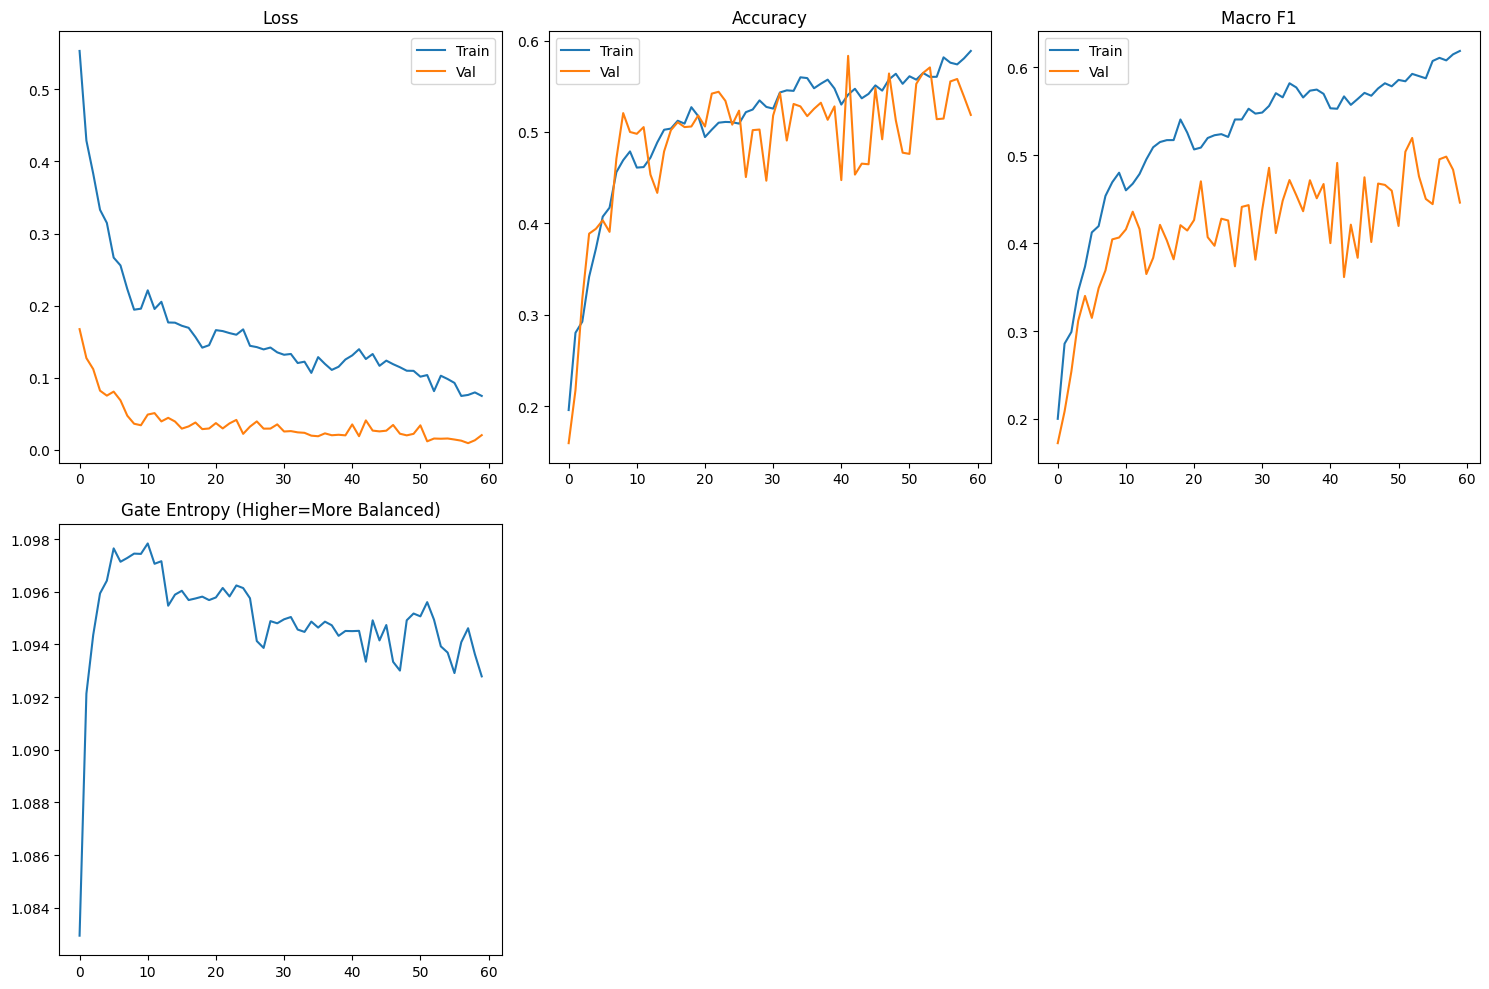


FINAL EVALUATION


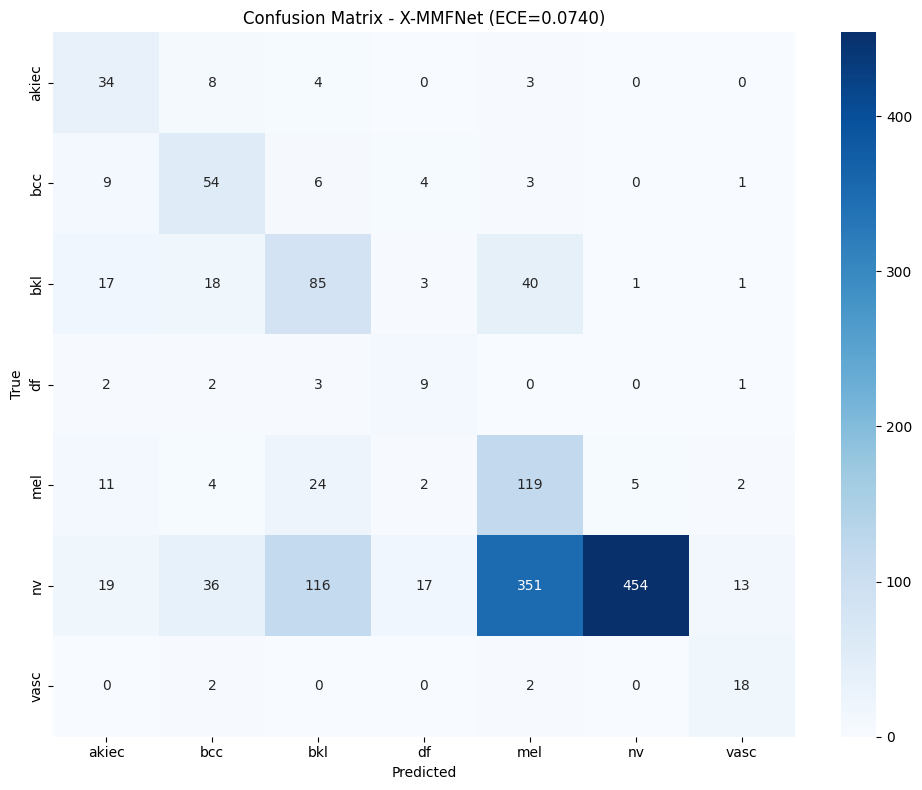


X-MMFNet FINAL TEST RESULTS
Accuracy: 0.5143
Macro F1: 0.4822
Weighted F1: 0.5557
Macro AUC: 0.9047
ECE: 0.0740 (Target < 0.05)
Mean Uncertainty Entropy: 1.1112
High Uncertainty Rate: 79.91% (flagged for review)

Per-class metrics:
  akiec : Precision=0.3696, Recall=0.6939, F1=0.4823
  bcc   : Precision=0.4355, Recall=0.7013, F1=0.5373
  bkl   : Precision=0.3571, Recall=0.5152, F1=0.4218
  df    : Precision=0.2571, Recall=0.5294, F1=0.3462
  mel   : Precision=0.2297, Recall=0.7126, F1=0.3474
  nv    : Precision=0.9870, Recall=0.4513, F1=0.6194
  vasc  : Precision=0.5000, Recall=0.8182, F1=0.6207

Target (beat V4-C): Accuracy >= 0.835, Macro F1 >= 0.733
NEEDS IMPROVEMENT

Generating TMEP dashboard...
Saved modality contribution chart to D:\Kimi phase 6\checkpoints\modality_contribution.png
Saved TMEP dashboard to D:\Kimi phase 6\checkpoints\tmep_dashboard.png

TMEP Results:
  MAS (Mask-Alignment Score): 0.183 (Target > 0.80)
  Modality Contribution: Image=0.339, Metadata=0.353, Morphol

In [27]:
# Plot + Test:
trainer.plot_history()
results, robustness = run_final_evaluation(model, test_loader, config, config.SAVE_DIR)